In [1]:
!pip install Pillow matplotlib numpy

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
import os
# Kết nối Google Drive
drive.mount('/content/drive')
# Thiết lập đường dẫn
THU_MUC_ANH = "/content/drive/MyDrive/Lab_ColorSpace/"
print("Hoàn tất cài đặt!")

Mounted at /content/drive
Hoàn tất cài đặt!


In [3]:
def setup_anh():
  global img_goc, danh_sach_anh
  # Lấy danh sách ảnh
  files = os.listdir(THU_MUC_ANH)
  danh_sach_anh = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
  print("Các ảnh có sẵn:")
  for i, file in enumerate(danh_sach_anh, 1):
   print(f"{i}. {file}")
  # Mở ảnh đầu tiên
  chon_anh = 0  # Thay đổi để chọn ảnh khác
  duong_dan = os.path.join(THU_MUC_ANH, danh_sach_anh[chon_anh])
  img_goc = Image.open(duong_dan)
  # Hiển thị thông tin ảnh
  print(f"\n  Thông tin ảnh: {danh_sach_anh[chon_anh]}")
  print(f"Kích thước: {img_goc.size}")
  print(f"Chế độ màu: {img_goc.mode}")
  print(f"Số pixel: {img_goc.width * img_goc.height:,}")
  # Hiển thị ảnh
  plt.figure(figsize=(8, 6))
  plt.imshow(img_goc)
  plt.title(f"Ảnh gốc: {danh_sach_anh[chon_anh]}")
  plt.axis('off')
  plt.show()
  return img_goc


Các ảnh có sẵn:
1. bai3_flip_horizontal.png
2. bai3_rotate_270.png
3. bai3_rotate_180.png
4. bai3_flip_vertical.png
5. bai3_rotate_45.png

  Thông tin ảnh: bai3_flip_horizontal.png
Kích thước: (400, 267)
Chế độ màu: RGBA
Số pixel: 106,800


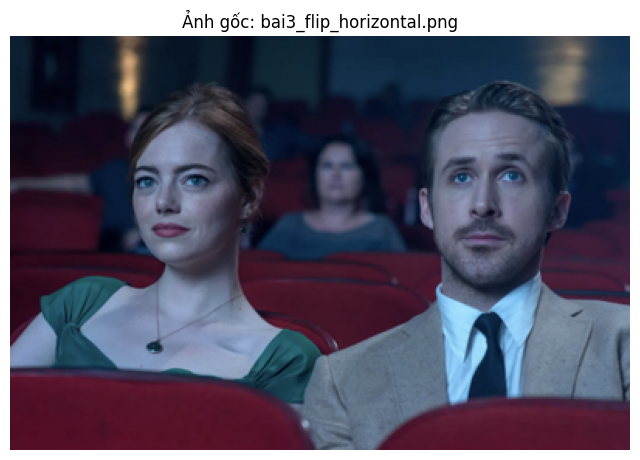

In [4]:
img_goc = setup_anh()

In [5]:
def chuyen_doi_grayscale():
  # Chuyển sang ảnh xám
  gray_img = img_goc.convert('L')
  # Tính toán thống kê
  gray_array = np.array(gray_img)
  mean_gray = np.mean(gray_array)
  std_gray = np.std(gray_array)
  # Hiển thị so sánh
  fig, axes = plt.subplots(1, 2, figsize=(12, 5))
  # Ảnh gốc
  axes[0].imshow(img_goc)
  axes[0].set_title('Ảnh gốc (RGB)')
  axes[0].axis('off')
  # Ảnh xám
  axes[1].imshow(gray_img, cmap='gray')
  axes[1].set_title(f'Ảnh xám\nMean: {mean_gray:.1f}, Std: {std_gray:.1f}')
  axes[1].axis('off')
  plt.tight_layout()
  plt.show()
  print(f"Đã chuyển sang ảnh xám")
  print(f"Độ sáng trung bình: {mean_gray:.2f}")
  print(f"Độ lệch chuẩn: {std_gray:.2f}")
  return gray_img


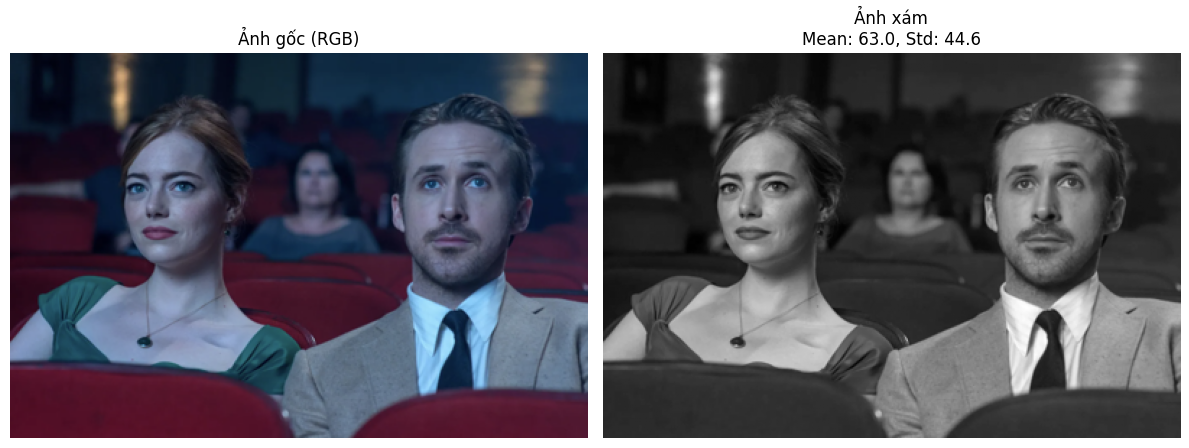

Đã chuyển sang ảnh xám
Độ sáng trung bình: 63.03
Độ lệch chuẩn: 44.64


In [6]:
gray_img = chuyen_doi_grayscale()

In [7]:
def chuyen_doi_hsv():
  # Chuyển sang HSV
  hsv_img = img_goc.convert('HSV')
  # Tách các kênh H, S, V
  h, s, v = hsv_img.split()
  # Hiển thị kết quả
  fig, axes = plt.subplots(2, 2, figsize=(12, 10))
  # Ảnh gốc
  axes[0, 0].imshow(img_goc)
  axes[0, 0].set_title('Ảnh gốc (RGB)')
  axes[0, 0].axis('off')
  # Ảnh HSV
  axes[0, 1].imshow(hsv_img)
  axes[0, 1].set_title('Ảnh HSV')
  axes[0, 1].axis('off')
  # Kênh Hue (màu sắc)
  axes[1, 0].imshow(h, cmap='hsv')
  axes[1, 0].set_title('Kênh H (Hue)')
  axes[1, 0].axis('off')
  # Kênh Saturation (độ bão hòa)
  axes[1, 1].imshow(s, cmap='gray')
  axes[1, 1].set_title('Kênh S (Saturation)')
  axes[1, 1].axis('off')
  plt.tight_layout()
  plt.show()
  print("Đã chuyển sang HSV")
  print("Lưu ý: HSV giúp phân tích màu sắc tốt hơn RGB")
  return hsv_img, h, s, v

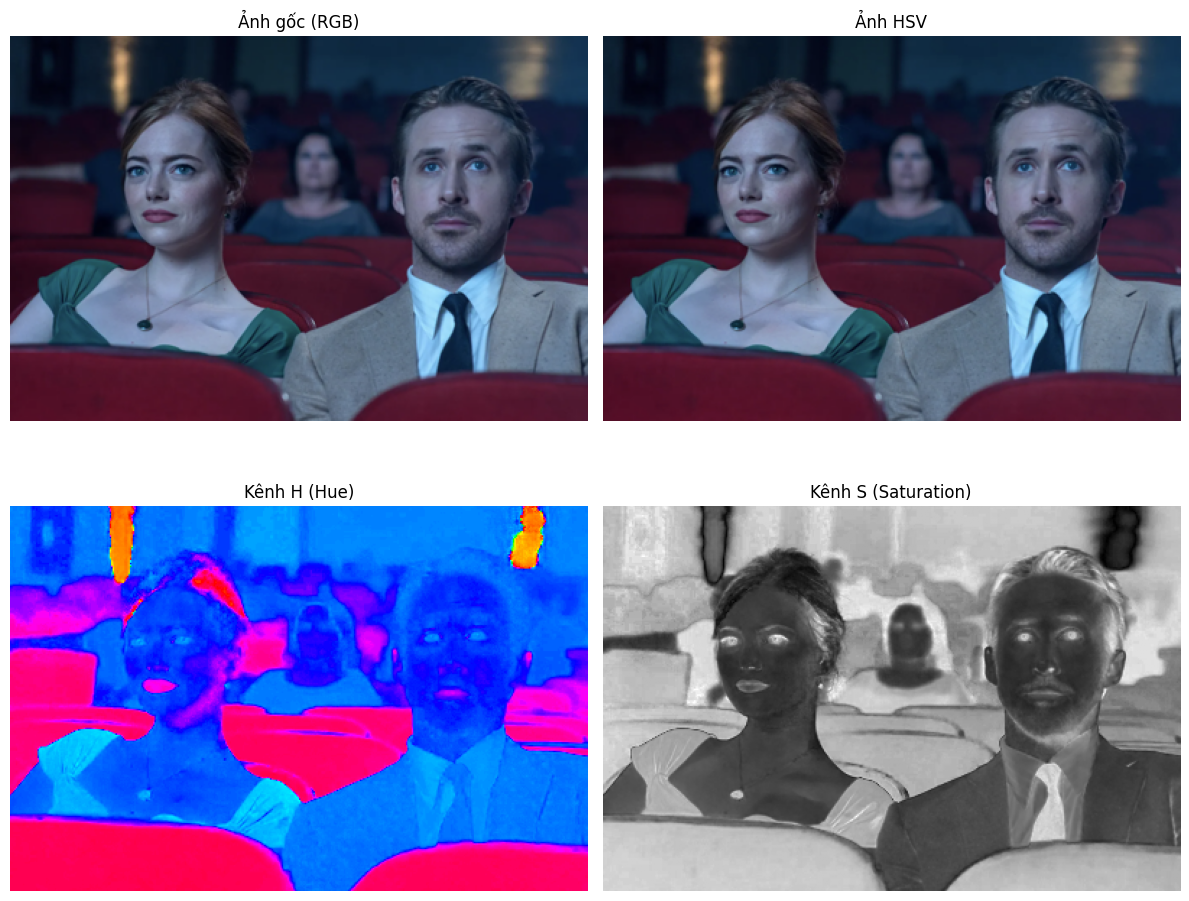

Đã chuyển sang HSV
Lưu ý: HSV giúp phân tích màu sắc tốt hơn RGB


In [8]:
hsv_img, h_channel, s_channel, v_channel = chuyen_doi_hsv()

In [9]:
def tao_anh_nhi_phan():
  # Chuyển sang ảnh xám trước
  gray = img_goc.convert('L')
  # Thử với các ngưỡng khác nhau
  thresholds = [64, 128, 192]
  fig, axes = plt.subplots(2, 2, figsize=(12, 10))
  # Ảnh xám gốc
  axes[0, 0].imshow(gray , cmap='gray')
  axes[0, 0].set_title('Ảnh xám gốc')
  axes[0, 0].axis('off')
  # Các ngưỡng khác nhau
  for i, threshold in enumerate(thresholds):
    binary_img = gray .point(lambda x: 0 if x < threshold else 255, '1')
  if i < 3:
    row , col = (0, 1) if i == 0 else (1, i-1)
    axes[row , col].imshow(binary_img, cmap='gray')
    axes[row , col].set_title(f'Binary (threshold={threshold})')
    axes[row , col].axis('off')
  plt.tight_layout()
  plt.show()
  # Trả về ảnh binary với ngưỡng 128
  binary_img = gray .point(lambda x: 0 if x < 128 else 255, '1')
  print("Đã tạo ảnh nhị phân")
  print("Thử các ngưỡng khác nhau để có kết quả tốt nhất")
  return binary_img


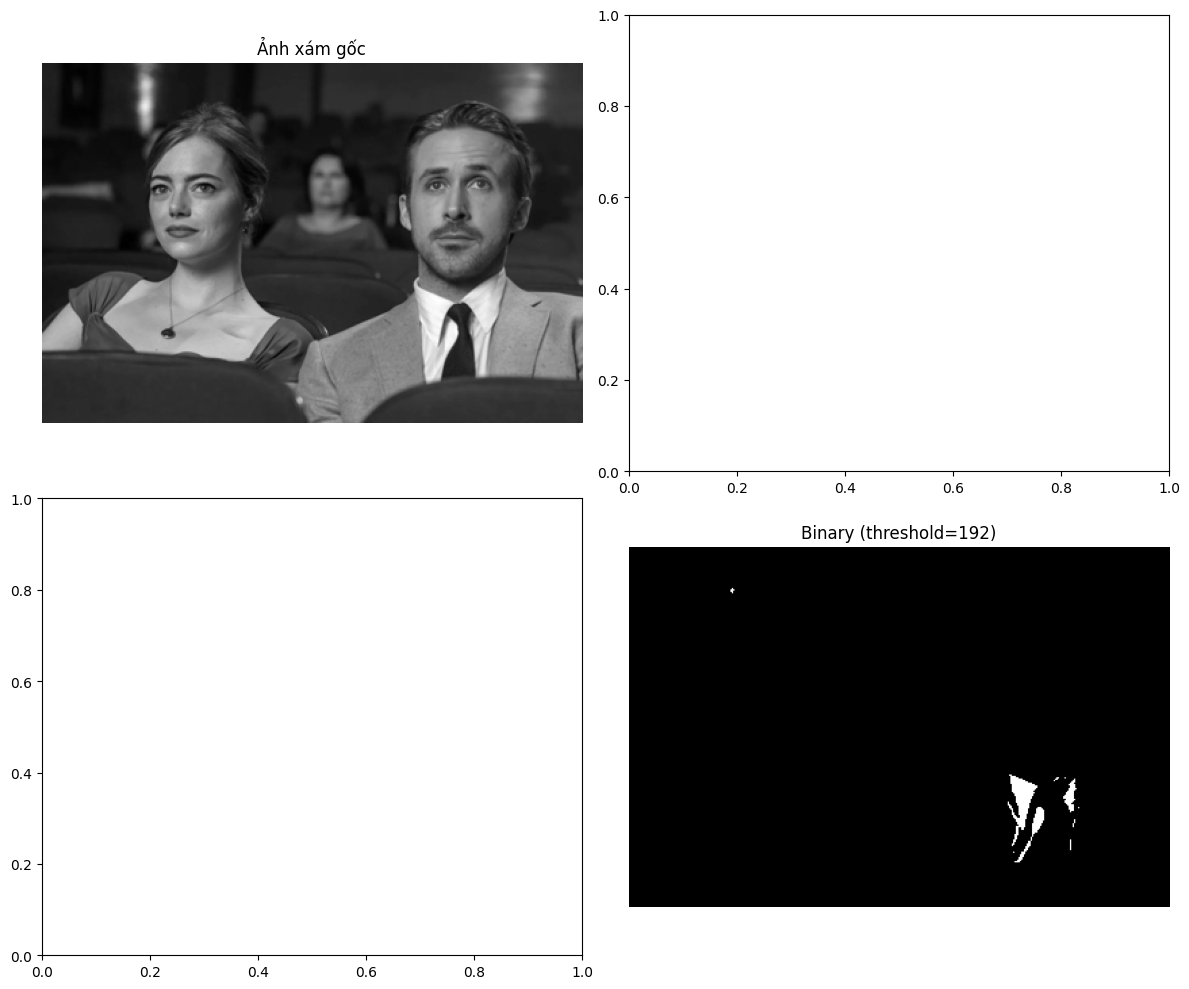

Đã tạo ảnh nhị phân
Thử các ngưỡng khác nhau để có kết quả tốt nhất


In [10]:
binary_img = tao_anh_nhi_phan()

In [11]:
def create_sepia(image):
    # Convert the image to RGB if it's in RGBA mode
    if image.mode == 'RGBA':
        image = image.convert('RGB')

    img_array = np.array(image)
    if len(img_array .shape) == 3:
      # Ma trận sepia chuẩn
      sepia_matrix = np.array([
      [0.393, 0.769, 0.189],
      [0.349, 0.686, 0.168],
      [0.272, 0.534, 0.131]
      ])
      sepia_array = img_array.dot(sepia_matrix.T)
      sepia_array = np.clip(sepia_array , 0, 255).astype(np.uint8)
    return Image.fromarray(sepia_array)

def tao_hieu_ung_sepia():
# Ma trận chuyển đổi Sepia

    sepia_img = create_sepia(img_goc)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_goc)
    axes[0].set_title('Ảnh gốc')
    axes[0].axis('off')
    axes[1].imshow(sepia_img)
    axes[1].set_title('Hiệu ứng Sepia')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
    print("Đã tạo hiệu ứng Sepia")
    return sepia_img

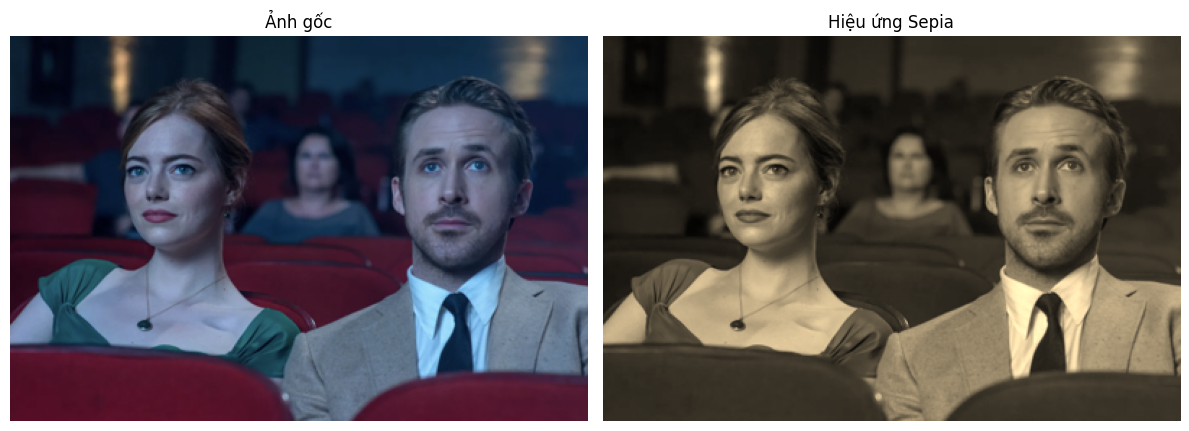

Đã tạo hiệu ứng Sepia


In [12]:
sepia_img = tao_hieu_ung_sepia()

In [13]:
def phan_tich_histogram():
  # Initialize RGB arrays to prevent UnboundLocalError
  r_array = np.array([])
  g_array = np.array([])
  b_array = np.array([])

  # Histogram ảnh xám
  gray_array = np.array(gray_img)

  # Create a figure for both histograms unconditionally
  fig, axes = plt.subplots(1, 2, figsize=(15, 5))

  # Plot Grayscale Histogram (always runs)
  axes[0].hist(gray_array.flatten(), bins=256, range=[0, 256],
  color='gray', alpha=0.7, edgecolor='black')
  axes[0].set_title('Histogram ảnh xám')
  axes[0].set_xlabel('Giá trị pixel')
  axes[0].set_ylabel('Tần suất')
  axes[0].grid(True, alpha=0.3)
  # Thống kê ảnh xám
  axes[0].axvline(np.mean(gray_array), color='red', linestyle='--',
  label=f'Mean: {np.mean(gray_array):.1f}')
  axes[0].legend()

  # Prepare RGB image and its channels for RGB histogram
  # Convert img_goc to RGB if it's not already, to ensure channel splitting works
  rgb_img_for_hist = img_goc
  if img_goc.mode != 'RGB':
      rgb_img_for_hist = img_goc.convert('RGB')

  # Ensure channel splitting and array conversion happen
  r, g, b = rgb_img_for_hist.split()
  r_array = np.array(r)
  g_array = np.array(g)
  b_array = np.array(b)

  # Plot RGB Histograms (always runs after conversion)
  axes[1].hist(r_array.flatten(), bins=256, range=[0, 256],
  color='red', alpha=0.5, label='Red')
  axes[1].hist(g_array.flatten(), bins=256, range=[0, 256],
  color='green', alpha=0.5, label='Green')
  axes[1].hist(b_array.flatten(), bins=256, range=[0, 256],
  color='blue', alpha=0.5, label='Blue')
  axes[1].set_title('Histogram các kênh RGB')
  axes[1].set_xlabel('Giá trị pixel')
  axes[1].set_ylabel('Tần suất')
  axes[1].legend()
  axes[1].grid(True, alpha=0.3)

  # In thống kê (these variables are now guaranteed to be defined)
  print("Thống kê các kênh màu:")
  if r_array.size > 0: # Check if arrays are not empty before computing mean
    print(f"Kênh đỏ - Mean: {np.mean(r_array):.2f}")
    print(f"Kênh xanh lá - Mean: {np.mean(g_array):.2f}")
    print(f"Kênh xanh dương - Mean: {np.mean(b_array):.2f}")
  else:
    print("RGB channel data not available for statistics.")

  plt.tight_layout()
  plt.show()

Thống kê các kênh màu:
Kênh đỏ - Mean: 62.16
Kênh xanh lá - Mean: 59.81
Kênh xanh dương - Mean: 81.87


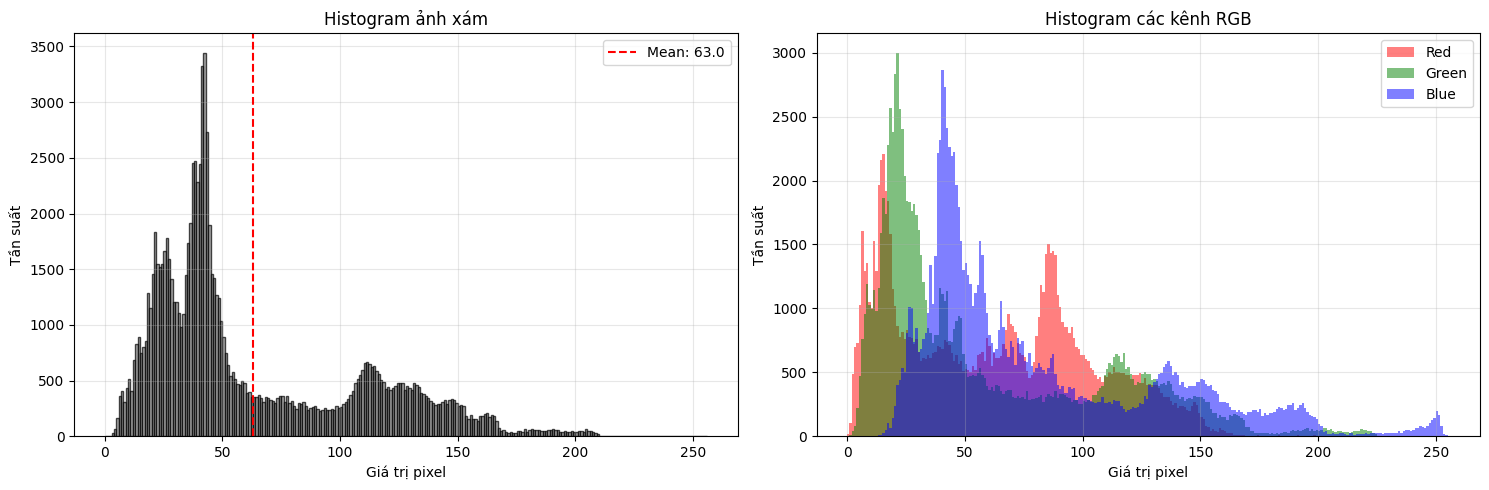

In [14]:
phan_tich_histogram()

In [17]:
def create_sepia(image):
  img_array = np.array(image)
  if len(img_array.shape) == 3:
    sepia_matrix = np.array([
    [0.393, 0.769, 0.189],
    [0.349, 0.686, 0.168],
    [0.272, 0.534, 0.131]
    ])
    sepia_array = img_array.dot(sepia_matrix.T)
    sepia_array = np.clip(sepia_array, 0, 255).astype(np.uint8)
  return Image.fromarray(sepia_array)

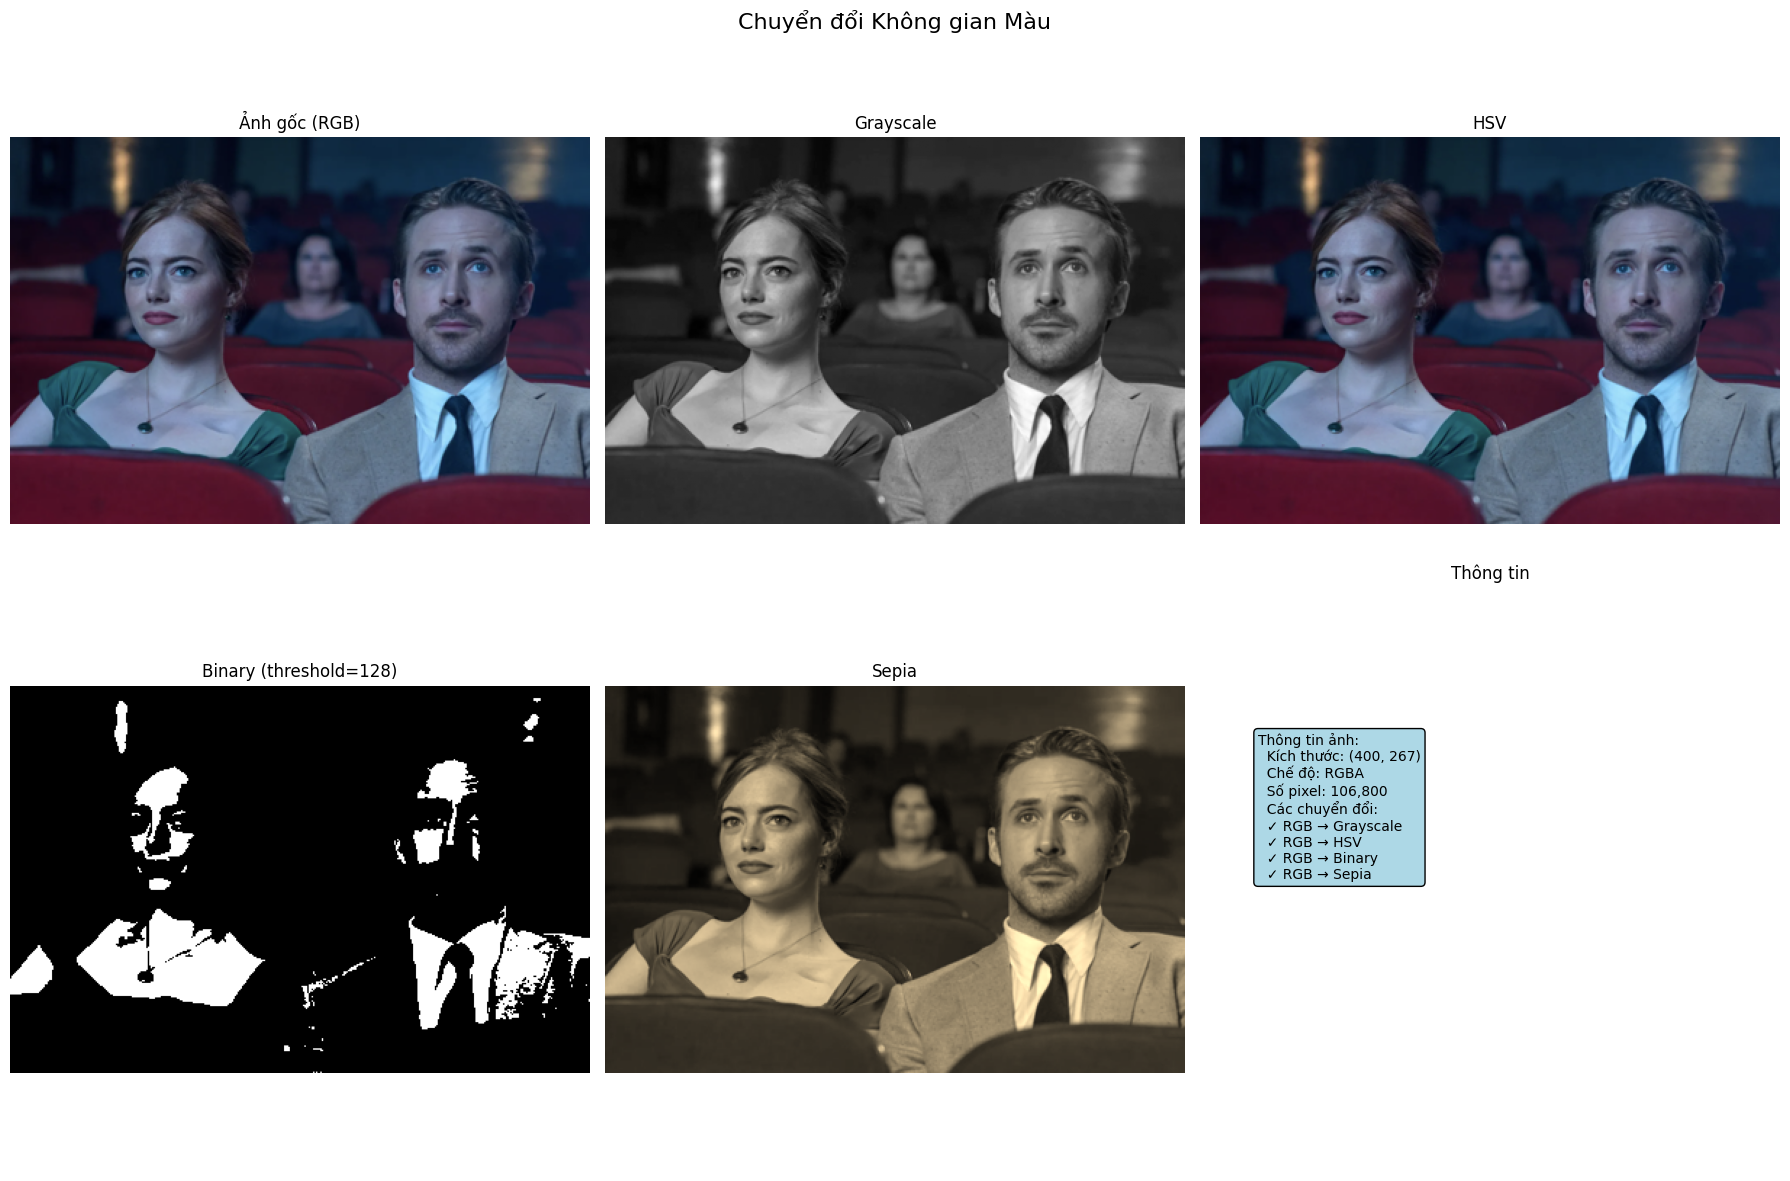

In [19]:
def tong_hop_chuyen_doi():
  # Tạo tất cả chuyển đổi
  gray = img_goc.convert('L')
  hsv = img_goc.convert('HSV')
  binary = gray.point(lambda x: 0 if x < 128 else 255, '1')

  # Ensure image is RGB for sepia conversion
  # img_goc might be RGBA, and create_sepia expects RGB if not handled internally
  sepia_input_img = img_goc
  if img_goc.mode == 'RGBA':
      sepia_input_img = img_goc.convert('RGB')

  sepia = create_sepia(sepia_input_img) # Pass the RGB version for sepia transformation
  # Hiển thị grid
  fig, axes = plt.subplots(2, 3, figsize=(18, 12))
  fig.suptitle('Chuyển đổi Không gian Màu', fontsize=16)
  # Ảnh gốc
  axes[0, 0].imshow(img_goc)
  axes[0, 0].set_title('Ảnh gốc (RGB)')
  axes[0, 0].axis('off')
  # Ảnh xám
  axes[0, 1].imshow(gray, cmap='gray')
  axes[0, 1].set_title('Grayscale')
  axes[0, 1].axis('off')
  # HSV
  axes[0, 2].imshow(hsv)
  axes[0, 2].set_title('HSV')
  axes[0, 2].axis('off')
  # Binary
  axes[1, 0].imshow(binary, cmap='gray')
  axes[1, 0].set_title('Binary (threshold=128)')
  axes[1, 0].axis('off')
  # Sepia
  axes[1, 1].imshow(sepia)
  axes[1, 1].set_title('Sepia')
  axes[1, 1].axis('off')
  # Thông tin
  info_text = f"""Thông tin ảnh:
  Kích thước: {img_goc.size}
  Chế độ: {img_goc.mode}
  Số pixel: {img_goc.width * img_goc.height:,}
  Các chuyển đổi:
  ✓ RGB → Grayscale
  ✓ RGB → HSV
  ✓ RGB → Binary
  ✓ RGB → Sepia"""
  axes[1, 2].text(0.1, 0.5, info_text, fontsize=10,
  transform=axes[1, 2].transAxes,
  bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
  axes[1, 2].set_title('Thông tin')
  axes[1, 2].axis('off')
  plt.tight_layout()
  plt.show()
  return gray, hsv, binary, sepia
gray_final, hsv_final, binary_final, sepia_final = tong_hop_chuyen_doi()

In [22]:
def luu_ket_qua():
  # Tạo thư mục kết quả
  thu_muc_ket_qua = "/content/drive/MyDrive/Lab_ColorSpace_Results/"
  if not os.path.exists(thu_muc_ket_qua):
    os.makedirs(thu_muc_ket_qua)

  # Tạo lại các chuyển đổi để lưu
  gray = img_goc.convert('L')
  hsv = img_goc.convert('HSV')
  binary = gray.point(lambda x: 0 if x < 128 else 255, '1')

  # Sepia - handle RGBA to RGB conversion
  sepia_input_img = img_goc
  if img_goc.mode == 'RGBA':
      sepia_input_img = img_goc.convert('RGB')

  img_array = np.array(sepia_input_img) # Use the potentially converted image
  sepia_matrix = np.array([
  [0.393, 0.769, 0.189],
  [0.349, 0.686, 0.168],
  [0.272, 0.534, 0.131]
  ])
  sepia_array = img_array.dot(sepia_matrix.T)
  sepia_array = np.clip(sepia_array, 0, 255).astype(np.uint8)
  sepia = Image.fromarray(sepia_array)

  # Lưu file
  ten_anh_goc = os.path.splitext(danh_sach_anh[0])[0]
  cac_chuyen_doi = {
  'grayscale': gray,
  'hsv': hsv.convert('RGB'),  # Chuyển về RGB để lưu
  'binary': binary.convert('RGB'),
  'sepia': sepia
  }
  for ten, anh in cac_chuyen_doi.items():
    filename = f"{ten_anh_goc}_{ten}.jpg"
    filepath = os.path.join(thu_muc_ket_qua, filename)
    anh.save(filepath, quality=95)
    print(f"✓ Đã lưu: {filename}")
  print(f"\nTất cả ảnh đã lưu tại: {thu_muc_ket_qua}")
luu_ket_qua()

✓ Đã lưu: bai3_flip_horizontal_grayscale.jpg
✓ Đã lưu: bai3_flip_horizontal_hsv.jpg
✓ Đã lưu: bai3_flip_horizontal_binary.jpg
✓ Đã lưu: bai3_flip_horizontal_sepia.jpg

Tất cả ảnh đã lưu tại: /content/drive/MyDrive/Lab_ColorSpace_Results/
